# Trade-size distribution

Value each swap in USD via a **causal** (past-only) trailing-hour average of the Kraken CEX
price, and build the pooled trade-size distribution. Its quantiles are the reference trade
sizes used by `arbitrage_index.ipynb`. Parameters come from `arblib.config.STUDY`.

> Note: since the swap extract is aggregated to one **end-of-block** row per (pool, block),
> the `amount0` / `amount1` here are the **last swap of each block** — so this is a
> per-(pool, block)-last-swap trade-size distribution, not one row per individual swap.

In [1]:
%load_ext autoreload
%autoreload 2

from arblib import data_io, sizing, preprocessing, plotting
from arblib.config import STUDY as S

dfs = data_io.load_pool_csvs(S.swaps_dir)
swaps = sizing.pooled_swaps(dfs)
x_usd = data_io.load_price_series(S.x_price_path)
y_usd = data_io.load_price_series(S.y_price_path)

Loaded: df_uniswap_swap.csv
     amount0             amount1         dex  evt_block_number  \
0 -237871959   80000000000000000  uniswap_v3          24131870   
1   77424560  -26056274730796998  uniswap_v4          24131871   
2 -310555978  104444082993705986  uniswap_v3          24131871   
3   -7350000    2472651595603797  uniswap_v3          24131873   
4   82701586  -27808804678588136  uniswap_v3          24131873   

                evt_block_time  fee            liquidity  nb_swaps  \
0  2025-12-31 10:00:11.000 UTC  100   159135392615244153         1   
1  2025-12-31 10:00:23.000 UTC  500    17769293247749556         1   
2  2025-12-31 10:00:23.000 UTC  100   159135392615244153         3   
3  2025-12-31 10:00:59.000 UTC  500  1267918869826850600         1   
4  2025-12-31 10:00:59.000 UTC  100   159135392615244153         1   

                                                pool  \
0         0xe0554a476a092703abdb3ef35c80e0d76d32939f   
1  0x4f88f7c99022eace4740c6898f59ce6a2e798

## 1. Verify token identity ↔ decimals

In [2]:
preprocessing.verify_token_decimals(swaps, S.token0, S.token1)

0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48 -> 6 decimals
0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2 -> 18 decimals

OK: token0 (6 dp), token1 (18 dp) consistent across all pools.


## 2. Human + USD amounts

In [3]:
swaps = sizing.add_usd_amounts(swaps, x_usd, y_usd, S.cex_avg_window_min)
swaps[["time", "x_rate", "y_rate", "amount0_h", "amount0_usd", "amount1_h", "amount1_usd"]].head()

,time,x_rate,y_rate,amount0_h,amount0_usd,amount1_h,amount1_usd
0,2025-12-31 10:00:11+00:00,0.999563,2970.031833,-237.871959,-237.768088,0.080000,237.602547
1,2025-12-31 10:00:23+00:00,0.999563,2970.031833,77.424560,77.390751,-0.026056,-77.387965
2,2025-12-31 10:00:23+00:00,0.999563,2970.031833,-310.555978,-310.420369,0.104444,310.202251
3,2025-12-31 10:00:59+00:00,0.999563,2970.031833,82.701586,82.665473,-0.027809,-82.593035
4,2025-12-31 10:00:59+00:00,0.999563,2970.031833,-109.975563,-109.927540,0.036986,109.848279


## 3. Split by direction (the in-leg of each swap)

In [4]:
x_in, y_in = sizing.split_in_legs(swaps)

Kept 434 of 459 swaps after dust filter
token0-in: 203 swaps | token1-in: 231 swaps


## 4. Trade-size distributions (per leg)

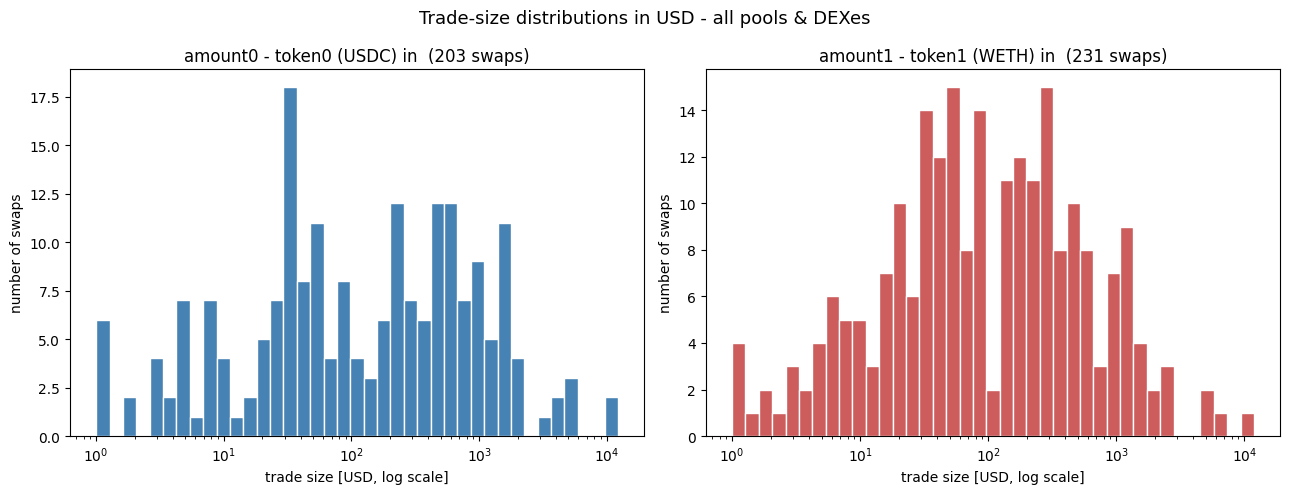

In [5]:
plotting.plot_trade_size_distributions(x_in, y_in, S.token0.symbol, S.token1.symbol)

## 5. Global distribution & reference quantiles

0.2     20.122969
0.4     53.289795
0.6    207.252162
0.8    588.429308
dtype: float64


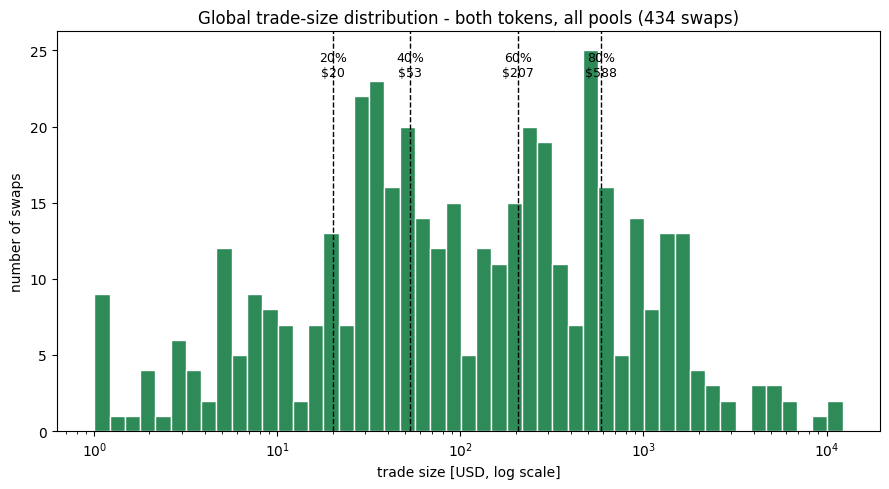

In [6]:
trade_sizes = sizing.pooled_trade_sizes(x_in, y_in)
quantiles = sizing.trade_size_quantiles(trade_sizes, list(S.reference_quantiles))
print(quantiles)
plotting.plot_global_trade_size(trade_sizes, quantiles)

## 6. Save the reference trade sizes

In [7]:
data_io.save_quantiles(quantiles, S.quantiles_path)

Saved: /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/WETH_USDC/data_analysis/trade_size_quantiles.csv
